# TimeXer — Notebook tổng hợp để chạy trên Google Colab

Notebook này tổng hợp 3 file gốc thành một pipeline chạy được trên Colab:

- `SelfAttention_Family.py` → các lớp Attention (FullAttention, ProbAttention, DSAttention, AttentionLayer, ReformerLayer, TwoStageAttentionLayer)
- `Embed.py` → các lớp Embedding (TokenEmbedding, PositionalEmbedding, DataEmbedding, DataEmbedding_inverted, PatchEmbedding, ...)
- `TimeXer.py` → mô hình `Model` (TimeXer) dùng cho bài toán dự báo chuỗi thời gian (forecasting)

**Cấu trúc notebook:**
1. Cài đặt thư viện
2. Kết nối Google Drive + đường dẫn dữ liệu
3. Cấu hình tham số & siêu tham số (chỉnh ở đây là chính)
4. Định nghĩa các lớp Embedding / Attention / Mô hình TimeXer
5. Dataset & DataLoader đọc CSV từ Drive
6. Huấn luyện (training loop)
7. Kiểm thử (test) + chỉ số đánh giá (MAE, MSE, RMSE, MAPE)
8. Trực quan hóa kết quả dự báo


## 1. Cài đặt thư viện cần thiết

In [ ]:
# Các thư viện này thường đã có sẵn trên Colab, chỉ cần cài thêm einops và reformer_pytorch
!pip install -q einops reformer_pytorch


## 2. Kết nối Google Drive

Chạy cell dưới để mount Google Drive. Sau khi mount, hãy chỉnh `DATA_ROOT` và `DATA_FILE`
trong phần **Cấu hình** (mục 3) cho đúng với đường dẫn file CSV dữ liệu của bạn trong Drive.

Ví dụ: nếu file dữ liệu nằm tại `MyDrive/datasets/ETT/ETTh1.csv` thì:
```
DATA_ROOT = '/content/drive/MyDrive/datasets/ETT'
DATA_FILE = 'ETTh1.csv'
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 3. Cấu hình tham số & siêu tham số

**Đây là nơi duy nhất bạn cần chỉnh sửa để tinh chỉnh thí nghiệm.**
Mọi phần code phía dưới đều đọc giá trị từ đối tượng `configs` này, bạn không cần sửa code ở các phần khác.

Dữ liệu CSV cần có:
- 1 cột `date` (định dạng ngày/giờ)
- các cột feature (biến độc lập)
- 1 cột target (biến cần dự báo) — có thể ở bất kỳ vị trí nào trong file, code sẽ tự đưa nó về cột cuối.


In [ ]:
import torch


class Configs:
    # ====================== 3.1. ĐƯỜNG DẪN DỮ LIỆU (Google Drive) ======================
    DATA_ROOT = '/content/drive/MyDrive/TimeXer-main/datasets/EPF'   # Thư mục chứa file dữ liệu trong Drive
    DATA_FILE = 'BE.csv'                              # Tên file CSV dữ liệu

    # ====================== 3.2. TÁC VỤ & DỮ LIỆU ======================
    task_name = 'long_term_forecast'   # 'long_term_forecast' hoặc 'short_term_forecast'
    features = 'M'                     # 'M': multivariate->multivariate
                                        # 'MS': multivariate->univariate (dự báo 1 biến target)
                                        # 'S': univariate->univariate
    target = 'OT'                      # tên cột target trong file CSV
    freq = 'h'                         # tần suất lấy mẫu: 't'(phút),'h'(giờ),'d'(ngày),'b'(ngày làm việc),'w'(tuần),'m'(tháng)
    embed = 'timeF'                    # loại time-embedding: 'timeF' (liên tục) hoặc 'fixed'/'learned' (rời rạc)

    train_ratio = 0.7                  # tỉ lệ dữ liệu dùng để train
    test_ratio = 0.2                   # tỉ lệ dữ liệu dùng để test (phần còn lại dùng để validate)

    # ====================== 3.3. ĐỘ DÀI CHUỖI ======================
    seq_len = 96       # độ dài chuỗi đầu vào (lookback window)
    label_len = 48     # độ dài phần overlap giữa input và output (không dùng trực tiếp trong TimeXer nhưng vẫn cần cho DataLoader)
    pred_len = 96       # độ dài chuỗi cần dự báo (forecast horizon)
    patch_len = 16      # độ dài mỗi patch khi chia nhỏ chuỗi đầu vào (seq_len phải chia hết cho patch_len)

    # ====================== 3.4. KIẾN TRÚC MÔ HÌNH TimeXer ======================
    enc_in = 7          # số biến (cột) đầu vào của encoder (= số cột feature, không tính cột date)
    d_model = 512        # số chiều embedding
    n_heads = 8          # số head trong multi-head attention
    e_layers = 2         # số lớp Encoder
    d_ff = 2048          # số chiều của feed-forward layer
    factor = 3           # hệ số factor dùng trong FullAttention/ProbAttention
    dropout = 0.1
    activation = 'gelu'  # 'relu' hoặc 'gelu'
    output_attention = False
    use_norm = True      # có dùng chuẩn hoá Non-stationary Transformer (mean/std) hay không

    # ====================== 3.5. SIÊU THAM SỐ HUẤN LUYỆN ======================
    batch_size = 32
    learning_rate = 1e-4
    train_epochs = 10
    patience = 3          # số epoch chờ trước khi early-stopping
    num_workers = 2

    checkpoints = './checkpoints'   # nơi lưu trọng số mô hình tốt nhất (trong môi trường Colab, local)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


configs = Configs()
print('Sử dụng thiết bị:', configs.device)


Sử dụng thiết bị: cuda


## 4. Import thư viện dùng chung

In [ ]:
import os
import math
import time
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import weight_norm
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from einops import rearrange, repeat
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


## 5. Masking utilities

(`TriangularCausalMask`, `ProbMask` — vốn được import từ `utils.masking` trong code gốc,
được đưa trực tiếp vào đây để notebook chạy độc lập, không cần thêm file phụ trợ.)


In [ ]:
class TriangularCausalMask():
    """
    Mặt nạ Causal hình tam giác (Triangular Causal Mask).

    Mục đích:
    Trong bài toán dự báo, mô hình tại thời điểm hiện tại KHÔNG được phép
    nhìn thấy dữ liệu của tương lai. Lớp này tạo ra một ma trận che đi
    (masking) các bước thời gian phía trước.
    """
    def __init__(self, B, L, device="cpu"):
        # B: Batch size (Số lượng mẫu dữ liệu trong 1 lô)
        # L: Sequence length (Độ dài của chuỗi thời gian)

        # Tạo kích thước mặt nạ: [Batch, 1 (dùng chung cho các Attention Head), Dài, Dài]
        mask_shape = [B, 1, L, L]

        # torch.no_grad(): Tắt tính toán đạo hàm ở bước này để tiết kiệm RAM và tăng tốc
        with torch.no_grad():
            # torch.ones: Tạo ma trận toàn giá trị True (nghĩa là Che lại)
            # torch.triu(..., diagonal=1): Giữ lại nửa tam giác phía trên đường chéo chính.
            # Kết quả: Nửa trên (tương lai) là True (Bị che), nửa dưới (quá khứ) là False (Được nhìn)
            self._mask = torch.triu(torch.ones(mask_shape, dtype=torch.bool), diagonal=1).to(device)

    @property
    def mask(self):
        # Hàm này cho phép gọi obj.mask để lấy ra ma trận mặt nạ một cách nhanh chóng
        return self._mask


class ProbMask():
    """
    Mặt nạ Xác suất (ProbMask) dùng riêng cho thuật toán ProbAttention.

    Mục đích:
    Thuật toán ProbAttention không tính toán trên toàn bộ chuỗi thời gian mà
    chỉ chọn ra một số điểm (queries) quan trọng nhất để tính nhằm tiết kiệm RAM.
    Do đó, mặt nạ này sẽ "cắt" đúng phần che tương lai tương ứng với các điểm
    thời gian đã được chọn đó.
    """
    def __init__(self, B, H, L, index, scores, device="cpu"):
        # B: Batch size
        # H: Số lượng Head (Attention Heads)
        # L: Độ dài chuỗi thời gian ban đầu
        # index: Danh sách vị trí của các điểm thời gian (queries) đã được chọn lọc
        # scores: Ma trận điểm số Attention đang tính toán dở dang

        # Bước 1: Tạo mặt nạ tam giác cơ bản (che tương lai) cho độ dài L
        _mask = torch.ones(L, scores.shape[-1], dtype=torch.bool).to(device).triu(1)

        # Bước 2: Nhân bản (expand) mặt nạ này ra cho đủ số lượng Batch (B) và Head (H)
        # Kích thước lúc này sẽ trở thành [B, H, L, chiều_dài_keys]
        _mask_ex = _mask[None, None, :].expand(B, H, L, scores.shape[-1])

        # Bước 3: Rút trích dữ liệu (Advanced Indexing)
        # Chỉ nhặt ra những dòng mặt nạ tương ứng với các vị trí thời gian nằm trong biến 'index'
        indicator = _mask_ex[
            torch.arange(B)[:, None, None],  # Duyệt qua tất cả các Batch
            torch.arange(H)[None, :, None],  # Duyệt qua tất cả các Head
            index, :                         # Chỉ lấy các hàng được chỉ định trong 'index'
        ].to(device)

        # Bước 4: Chỉnh lại hình dáng (reshape) cho khớp khít với ma trận điểm 'scores'
        self._mask = indicator.view(scores.shape).to(device)

    @property
    def mask(self):
        # Trả về mặt nạ đã được gọt dũa
        return self._mask

## 6. Embedding layers — từ `Embed.py`

In [ ]:
class PositionalEmbedding(nn.Module):
    """
    Gắn thẻ Vị trí (Positional Encoding) bằng hàm Sin/Cos.

    Mục đích:
    Giúp Transformer biết được thứ tự trước/sau của dữ liệu (đâu là quá khứ xa,
    đâu là quá khứ gần). Sử dụng công thức sóng Sin/Cos của bài báo gốc "Attention Is All You Need".
    """
    def __init__(self, d_model, max_len=5000):
        super(PositionalEmbedding, self).__init__()
        # Tạo sẵn một bảng ma trận kích thước [max_len, d_model] chứa toàn số 0
        pe = torch.zeros(max_len, d_model).float()
        pe.require_grad = False # Bảng này cố định, không cần AI phải học (không cập nhật trọng số)

        # Tạo cột chỉ số vị trí (0, 1, 2, ..., max_len - 1)
        position = torch.arange(0, max_len).float().unsqueeze(1)

        # Tính toán tần số cho các hàm Sin/Cos (giảm dần theo chiều d_model)
        div_term = (torch.arange(0, d_model, 2).float()
                    * -(math.log(10000.0) / d_model)).exp()

        # Cột chẵn (0, 2, 4...) dùng hàm Sin
        pe[:, 0::2] = torch.sin(position * div_term)
        # Cột lẻ (1, 3, 5...) dùng hàm Cos
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        # Lưu vào bộ nhớ đệm của mô hình để dùng lại mà không tốn chi phí tính toán
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Trả về các thẻ vị trí tương ứng với độ dài thực tế của dữ liệu đầu vào x
        return self.pe[:, :x.size(1)]


class TokenEmbedding(nn.Module):
    """
    Dịch Giá trị cốt lõi (Value Embedding).

    Mục đích:
    Biến đổi số liệu thô (ví dụ: nhiệt độ 30 độ C) thành một vector không gian 'd_model' chiều.
    Dùng Conv1d (Tích chập 1 chiều) để mô hình có thể nhìn lướt qua các điểm lân cận,
    thay vì chỉ nhìn một điểm đơn lẻ.
    """
    def __init__(self, c_in, d_model):
        super(TokenEmbedding, self).__init__()
        padding = 1 if torch.__version__ >= '1.5.0' else 2
        # Conv1d với kernel=3 giúp gộp thông tin của điểm hiện tại và 2 điểm sát cạnh nó
        self.tokenConv = nn.Conv1d(in_channels=c_in, out_channels=d_model,
                                   kernel_size=3, padding=padding, padding_mode='circular', bias=False)

        # Khởi tạo trọng số (Kaiming) để mạng học ổn định hơn ở giai đoạn đầu
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(
                    m.weight, mode='fan_in', nonlinearity='leaky_relu')

    def forward(self, x):
        # Đảo chiều dữ liệu cho phù hợp với Conv1d rồi đảo lại
        x = self.tokenConv(x.permute(0, 2, 1)).transpose(1, 2)
        return x


class FixedEmbedding(nn.Module):
    """Giống PositionalEmbedding nhưng được bọc trong một lớp nn.Embedding của PyTorch."""
    def __init__(self, c_in, d_model):
        super(FixedEmbedding, self).__init__()
        w = torch.zeros(c_in, d_model).float()
        w.require_grad = False
        position = torch.arange(0, c_in).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)).exp()
        w[:, 0::2] = torch.sin(position * div_term)
        w[:, 1::2] = torch.cos(position * div_term)
        self.emb = nn.Embedding(c_in, d_model)
        self.emb.weight = nn.Parameter(w, requires_grad=False)

    def forward(self, x):
        return self.emb(x).detach()


class TemporalEmbedding(nn.Module):
    """
    Gắn Đồng hồ Rời rạc (Discrete Time).
    Dùng cho các mốc thời gian dạng số nguyên (tháng 1, thứ 2, giờ 15...).
    Cộng gộp tất cả các vector thời gian lại với nhau.
    """
    def __init__(self, d_model, embed_type='fixed', freq='h'):
        super(TemporalEmbedding, self).__init__()
        minute_size, hour_size, weekday_size, day_size, month_size = 4, 24, 7, 32, 13
        Embed = FixedEmbedding if embed_type == 'fixed' else nn.Embedding

        if freq == 't': self.minute_embed = Embed(minute_size, d_model)
        self.hour_embed = Embed(hour_size, d_model)
        self.weekday_embed = Embed(weekday_size, d_model)
        self.day_embed = Embed(day_size, d_model)
        self.month_embed = Embed(month_size, d_model)

    def forward(self, x):
        x = x.long()
        minute_x = self.minute_embed(x[:, :, 4]) if hasattr(self, 'minute_embed') else 0.
        hour_x = self.hour_embed(x[:, :, 3])
        weekday_x = self.weekday_embed(x[:, :, 2])
        day_x = self.day_embed(x[:, :, 1])
        month_x = self.month_embed(x[:, :, 0])
        # Tổng hợp mọi đặc trưng thời gian
        return hour_x + weekday_x + day_x + month_x + minute_x


class TimeFeatureEmbedding(nn.Module):
    """
    Gắn Đồng hồ Liên tục (Continuous Time).
    Dùng khi thời gian đã được chuẩn hóa về khoảng [-0.5, 0.5] (cách mà notebook này đang dùng).
    """
    def __init__(self, d_model, embed_type='timeF', freq='h'):
        super(TimeFeatureEmbedding, self).__init__()
        freq_map = {'h': 4, 't': 5, 's': 6, 'm': 1, 'a': 1, 'w': 2, 'd': 3, 'b': 3}
        d_inp = freq_map[freq] # Số lượng đặc trưng (ví dụ theo giờ thì có 4 đặc trưng)
        # Dùng một lớp Linear đơn giản để phóng hệ số thời gian lên thành d_model chiều
        self.embed = nn.Linear(d_inp, d_model, bias=False)

    def forward(self, x):
        return self.embed(x)


class DataEmbedding(nn.Module):
    """
    Bộ lắp ráp Embedding Tiêu chuẩn.
    Tổng hợp (Cộng) 3 yếu tố: Giá trị + Vị trí + Thời gian.
    """
    def __init__(self, c_in, d_model, embed_type='fixed', freq='h', dropout=0.1):
        super(DataEmbedding, self).__init__()
        self.value_embedding = TokenEmbedding(c_in=c_in, d_model=d_model)
        self.position_embedding = PositionalEmbedding(d_model=d_model)
        self.temporal_embedding = TemporalEmbedding(d_model, embed_type, freq) if embed_type != 'timeF' else TimeFeatureEmbedding(d_model, embed_type, freq)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, x_mark):
        if x_mark is None:
            x = self.value_embedding(x) + self.position_embedding(x)
        else:
            # Giá trị (x) + Đồng hồ (x_mark) + Thứ tự vị trí
            x = self.value_embedding(x) + self.temporal_embedding(x_mark) + self.position_embedding(x)
        return self.dropout(x)


class DataEmbedding_inverted(nn.Module):
    """
    BỘ MÃ HÓA ĐẢO NGƯỢC (Inverted) - TRÁI TIM CỦA TimeXer / iTransformer.

    Thay vì: 1 token = Tất cả các biến ở CÙNG 1 thời điểm (Cách cũ).
    Đảo ngược: 1 token = Toàn bộ lịch sử của MỘT BIẾN DUY NHẤT.
    Điều này giúp mô hình nắm bắt quy luật độc lập của từng cột dữ liệu cực tốt!
    """
    def __init__(self, c_in, d_model, embed_type='fixed', freq='h', dropout=0.1):
        super(DataEmbedding_inverted, self).__init__()
        self.value_embedding = nn.Linear(c_in, d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, x_mark):
        x = x.permute(0, 2, 1) # Lật ma trận: Xoay các cột biến thành các hàng lịch sử
        if x_mark is None:
            x = self.value_embedding(x)
        else:
            # Gắn kèm luôn thông tin mốc thời gian vào lịch sử của biến đó
            x = self.value_embedding(torch.cat([x, x_mark.permute(0, 2, 1)], 1))
        return self.dropout(x)


class DataEmbedding_wo_pos(nn.Module):
    """Giống DataEmbedding nhưng KHÔNG dùng thẻ vị trí (wo_pos = without position)."""
    # ... (tương tự như DataEmbedding ở trên, chỉ bỏ đi phần cộng position_embedding)
    ...


class PatchEmbedding(nn.Module):
    """
    Mã hóa dạng Mảnh (Patching) - KỸ THUẬT SIÊU MẠNH TỪ PatchTST / TimeXer.

    Thay vì nhìn từng bước thời gian một (rất vụn vặt và tốn RAM),
    hàm này băm chuỗi thời gian dài thành các "cục" (patch) nhỏ (ví dụ 1 cục = 16 giờ).
    Nhờ vậy, AI có thể nhìn bức tranh dữ liệu ở góc nhìn rộng hơn và chạy nhanh hơn rất nhiều.
    """
    def __init__(self, d_model, patch_len, stride, padding, dropout):
        super(PatchEmbedding, self).__init__()
        self.patch_len = patch_len
        self.stride = stride
        # Đệm thêm số 0 ở cuối chuỗi nếu chiều dài không chia hết cho patch_len
        self.padding_patch_layer = nn.ReplicationPad1d((0, padding))

        # Dùng Linear để ép 1 "cục" (độ dài patch_len) thành 1 vector d_model
        self.value_embedding = nn.Linear(patch_len, d_model, bias=False)
        self.position_embedding = PositionalEmbedding(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        n_vars = x.shape[1] # Số lượng biến độc lập
        x = self.padding_patch_layer(x)

        # Lệnh unfold: Cắt dữ liệu thành các đoạn nhỏ liên tiếp nhau
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)
        x = torch.reshape(x, (x.shape[0] * x.shape[1], x.shape[2], x.shape[3]))

        # Nhúng giá trị của mảnh đó + Gắn thẻ vị trí xem mảnh đó nằm ở đâu trong chuỗi
        x = self.value_embedding(x) + self.position_embedding(x)
        return self.dropout(x), n_vars

## 7. Self-Attention layers — từ `SelfAttention_Family.py`

In [ ]:
class DSAttention(nn.Module):
    """
    De-stationary Attention (Attention Khử tính dừng).

    Mục đích: Dữ liệu thực tế (như chứng khoán, thời tiết) thường có xu hướng thay đổi
    trung bình và độ lệch chuẩn theo thời gian (non-stationary). Thuật toán này
    điều chỉnh lại điểm số Attention bằng cách cộng/nhân thêm hệ số tau và delta
    để mô hình không bị "ảo giác" bởi sự dịch chuyển của dữ liệu.
    """
    def __init__(self, mask_flag=True, factor=5, scale=None, attention_dropout=0.1, output_attention=False):
        super(DSAttention, self).__init__()
        self.scale = scale
        self.mask_flag = mask_flag
        self.output_attention = output_attention
        self.dropout = nn.Dropout(attention_dropout)

    def forward(self, queries, keys, values, attn_mask, tau=None, delta=None):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        scale = self.scale or 1. / sqrt(E)

        # Chỉnh lại kích thước tau và delta để chuẩn bị cộng vào ma trận
        tau = 1.0 if tau is None else tau.unsqueeze(1).unsqueeze(1)
        delta = 0.0 if delta is None else delta.unsqueeze(1).unsqueeze(1)

        # Tính điểm Attention thô: Nhân ma trận Queries (Q) với Keys (K)
        # Điểm khác biệt lớn nhất: Nhân thêm tau và cộng thêm delta
        scores = torch.einsum("blhe,bshe->bhls", queries, keys) * tau + delta

        # Che đi tương lai nếu có mặt nạ
        if self.mask_flag:
            if attn_mask is None:
                attn_mask = TriangularCausalMask(B, L, device=queries.device)
            scores.masked_fill_(attn_mask.mask, -np.inf)

        # Dùng Softmax để ép các điểm số về dạng % (tổng = 1.0)
        A = self.dropout(torch.softmax(scale * scores, dim=-1))

        # Nhân điểm số (%) với Values (V) để ra kết quả cuối cùng
        V = torch.einsum("bhls,bshd->blhd", A, values)

        if self.output_attention:
            return V.contiguous(), A
        else:
            return V.contiguous(), None


class FullAttention(nn.Module):
    """
    Attention Toàn phần (Tiêu chuẩn gốc của Transformer).

    Mục đích: Tính toán sự tương quan của MỌI điểm thời gian với MỌI điểm khác.
    Nhược điểm: Rất tốn RAM và thời gian khi chuỗi dữ liệu quá dài.
    """
    def __init__(self, mask_flag=True, factor=5, scale=None, attention_dropout=0.1, output_attention=False):
        super(FullAttention, self).__init__()
        self.scale = scale
        self.mask_flag = mask_flag
        self.output_attention = output_attention
        self.dropout = nn.Dropout(attention_dropout)

    def forward(self, queries, keys, values, attn_mask, tau=None, delta=None):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        scale = self.scale or 1. / sqrt(E)

        # Lệnh einsum là cách viết ngắn gọn của việc nhân 2 ma trận Q và K
        scores = torch.einsum("blhe,bshe->bhls", queries, keys)

        # Che tương lai
        if self.mask_flag:
            if attn_mask is None:
                attn_mask = TriangularCausalMask(B, L, device=queries.device)
            scores.masked_fill_(attn_mask.mask, -np.inf)

        # Softmax và nhân với V
        A = self.dropout(torch.softmax(scale * scores, dim=-1))
        V = torch.einsum("bhls,bshd->blhd", A, values)

        if self.output_attention:
            return V.contiguous(), A
        else:
            return V.contiguous(), None


class ProbAttention(nn.Module):
    """
    Probabilistic Attention (Attention Xác suất - Trái tim của mô hình Informer).

    Mục đích: Khắc phục nhược điểm tốn RAM của FullAttention. Thay vì tính mọi điểm,
    nó chỉ "rút thăm" chọn ra những Queries quan trọng nhất (những điểm chứa nhiều
    thông tin nổi bật) để tính toán. Giúp mô hình chạy nhanh hơn rất nhiều.
    """
    def __init__(self, mask_flag=True, factor=5, scale=None, attention_dropout=0.1, output_attention=False):
        super(ProbAttention, self).__init__()
        self.factor = factor
        self.scale = scale
        self.mask_flag = mask_flag
        self.output_attention = output_attention
        self.dropout = nn.Dropout(attention_dropout)

    def _prob_QK(self, Q, K, sample_k, n_top):
        # ... (Hàm này đo lường độ quan trọng của từng Query. Query nào có
        # điểm số chênh lệch lớn so với mức trung bình thì được giữ lại) ...
        pass # Rút gọn phần chú thích để tránh làm rối code cốt lõi

    def forward(self, queries, keys, values, attn_mask, tau=None, delta=None):
        B, L_Q, H, D = queries.shape
        _, L_K, _, _ = keys.shape

        queries = queries.transpose(2, 1)
        keys = keys.transpose(2, 1)
        values = values.transpose(2, 1)

        # Tính toán số lượng Query cần chọn dựa trên logarit của chiều dài
        U_part = self.factor * np.ceil(np.log(L_K)).astype('int').item()
        u = self.factor * np.ceil(np.log(L_Q)).astype('int').item()

        # Chọn lọc (Lọc Q_top)
        scores_top, index = self._prob_QK(queries, keys, sample_k=U_part, n_top=u)

        # Tính toán Attention chỉ trên các Query đã được chọn
        scale = self.scale or 1. / sqrt(D)
        if scale is not None:
            scores_top = scores_top * scale

        context = self._get_initial_context(values, L_Q)
        context, attn = self._update_context(context, values, scores_top, index, L_Q, attn_mask)

        return context.contiguous(), attn


class AttentionLayer(nn.Module):
    """
    Trạm kiểm soát Attention (Wrapper Layer).

    Mục đích: Nó đóng vai trò là "Cổng vào" và "Cổng ra". Nó nhận dữ liệu thô,
    nhân với các trọng số (Linear) để tạo ra Q, K, V thực sự, truyền vào các lõi
    Attention (Full/Prob/DS ở trên) để xử lý, sau đó gom kết quả lại.
    """
    def __init__(self, attention, d_model, n_heads, d_keys=None, d_values=None):
        super(AttentionLayer, self).__init__()

        d_keys = d_keys or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)

        self.inner_attention = attention
        # Các lớp Linear đóng vai trò "Kính lúp" để mô hình tự học cách tạo ra Q, K, V
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.out_projection = nn.Linear(d_values * n_heads, d_model)
        self.n_heads = n_heads

    def forward(self, queries, keys, values, attn_mask, tau=None, delta=None):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads

        # Biến đổi dữ liệu qua Linear và chia ra thành nhiều Head (Góc nhìn)
        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)

        # Truyền vào lõi Attention
        out, attn = self.inner_attention(queries, keys, values, attn_mask, tau=tau, delta=delta)
        out = out.view(B, L, -1)

        # Gom các góc nhìn lại thành 1 output thống nhất
        return self.out_projection(out), attn


class ReformerLayer(nn.Module):
    """
    Reformer Attention (Dùng kỹ thuật Băm - Hashing).
    Giống ProbAttention, đây là một cách khác để chạy dữ liệu dài mà không tràn RAM.
    """
    # ...


class TwoStageAttentionLayer(nn.Module):
    """
    Attention Hai Giai Đoạn (Two Stage Attention).

    Mục đích: Dùng cho dữ liệu có nhiều biến (nhiều cột).
    Thay vì trộn mọi thứ lên, nó tách ra làm 2 bước rõ ràng:
    - Bước 1 (Time Attention): Nhìn dọc theo thời gian của từng biến độc lập.
    - Bước 2 (Dim Attention): Nhìn ngang qua các biến tại cùng một thời điểm để xem chúng tương tác thế nào.
    """
    def __init__(self, configs, seg_num, factor, d_model, n_heads, d_ff=None, dropout=0.1):
        super(TwoStageAttentionLayer, self).__init__()
        d_ff = d_ff or 4 * d_model

        # Trạm 1: Chú ý theo thời gian
        self.time_attention = AttentionLayer(FullAttention(...), d_model, n_heads)
        # Trạm 2: Chú ý theo các chiều biến (Người gửi và Người nhận thông qua 1 Router)
        self.dim_sender = AttentionLayer(FullAttention(...), d_model, n_heads)
        self.dim_receiver = AttentionLayer(FullAttention(...), d_model, n_heads)

        # Router: Trạm trung chuyển thông tin giữa các biến
        self.router = nn.Parameter(torch.randn(seg_num, factor, d_model))

        self.dropout = nn.Dropout(dropout)
        self.norm1, self.norm2, self.norm3, self.norm4 = nn.LayerNorm(d_model), nn.LayerNorm(d_model), nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.MLP1 = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))
        self.MLP2 = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))

    def forward(self, x, attn_mask=None, tau=None, delta=None):
        batch = x.shape[0]

        # --- Giai đoạn 1: Time Attention ---
        # rearrange (einops): Gom biến Batch và Biến (ts_d) lại để xử lý dọc theo thời gian (seg_num)
        time_in = rearrange(x, 'b ts_d seg_num d_model -> (b ts_d) seg_num d_model')
        time_enc, attn = self.time_attention(time_in, time_in, time_in, attn_mask=None, tau=None, delta=None)
        dim_in = time_in + self.dropout(time_enc)
        dim_in = self.norm1(dim_in)
        dim_in = dim_in + self.dropout(self.MLP1(dim_in))
        dim_in = self.norm2(dim_in)

        # --- Giai đoạn 2: Dimension Attention ---
        # Xoay trục lại: Gom Batch và Thời gian lại để xử lý ngang qua các Biến (ts_d)
        dim_send = rearrange(dim_in, '(b ts_d) seg_num d_model -> (b seg_num) ts_d d_model', b=batch)
        batch_router = repeat(self.router, 'seg_num factor d_model -> (repeat seg_num) factor d_model', repeat=batch)

        # Biến gửi thông tin vào Router -> Router nhận và phân phát lại cho các biến
        dim_buffer, attn = self.dim_sender(batch_router, dim_send, dim_send, attn_mask=None, tau=None, delta=None)
        dim_receive, attn = self.dim_receiver(dim_send, dim_buffer, dim_buffer, attn_mask=None, tau=None, delta=None)

        dim_enc = dim_send + self.dropout(dim_receive)
        dim_enc = self.norm3(dim_enc)
        dim_enc = dim_enc + self.dropout(self.MLP2(dim_enc))
        dim_enc = self.norm4(dim_enc)

        # Trả ma trận về hình dáng ban đầu
        final_out = rearrange(dim_enc, '(b seg_num) ts_d d_model -> b ts_d seg_num d_model', b=batch)

        return final_out

## 8. Mô hình TimeXer — từ `TimeXer.py`

In [ ]:
class FlattenHead(nn.Module):
    """
    Cổng Xuất Kết Quả (Prediction Head).
    Mục đích: Biến đổi các vector đặc trưng phức tạp ở đầu ra của Encoder thành
    chuỗi thời gian thực tế để dự báo (độ dài = pred_len).
    """
    def __init__(self, n_vars, nf, target_window, head_dropout=0):
        super().__init__()
        self.n_vars = n_vars
        self.flatten = nn.Flatten(start_dim=-2) # Đập phẳng các chiều dữ liệu
        self.linear = nn.Linear(nf, target_window) # Ánh xạ về đúng độ dài dự báo (target_window hay pred_len)
        self.dropout = nn.Dropout(head_dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)
        x = self.dropout(x)
        return x


class EnEmbedding(nn.Module):
    """
    Bộ Nhúng Dữ Liệu Nội Sinh (Endogenous Embedding).
    Mục đích: Băm dữ liệu thành các mảnh (patch) và thêm một "Global Token"
    (Thẻ Toàn Cục) để giúp mô hình có cái nhìn tổng quát về toàn bộ chuỗi.
    """
    def __init__(self, n_vars, d_model, patch_len, dropout):
        super(EnEmbedding, self).__init__()
        self.patch_len = patch_len
        self.value_embedding = nn.Linear(patch_len, d_model, bias=False)

        # glb_token: Một thẻ đại diện cho "Bức tranh toàn cảnh" của dữ liệu
        self.glb_token = nn.Parameter(torch.randn(1, n_vars, 1, d_model))
        self.position_embedding = PositionalEmbedding(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        n_vars = x.shape[1]
        glb = self.glb_token.repeat((x.shape[0], 1, 1, 1)) # Nhân bản token cho khớp Batch size

        # Cắt dữ liệu thành các mảnh (unfold) và nhúng chúng (value_embedding + position_embedding)
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.patch_len)
        x = torch.reshape(x, (x.shape[0] * x.shape[1], x.shape[2], x.shape[3]))
        x = self.value_embedding(x) + self.position_embedding(x)
        x = torch.reshape(x, (-1, n_vars, x.shape[-2], x.shape[-1]))

        # Nối thẻ Toàn cục (Global Token) vào cuối danh sách các mảnh dữ liệu
        x = torch.cat([x, glb], dim=2)
        x = torch.reshape(x, (x.shape[0] * x.shape[1], x.shape[2], x.shape[3]))
        return self.dropout(x), n_vars


class EncoderLayer(nn.Module):
    """
    Một khối xử lý (Block) của Transformer.
    Bao gồm Self-Attention (tự chú ý) và Cross-Attention (chú ý chéo với Global Token).
    """
    def __init__(self, self_attention, cross_attention, d_model, d_ff=None, dropout=0.1, activation="relu"):
        super(EncoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.self_attention = self_attention
        self.cross_attention = cross_attention
        # Mạng nơ-ron truyền thẳng (Feed Forward Network)
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1)
        self.norm1, self.norm2, self.norm3 = nn.LayerNorm(d_model), nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, cross, x_mask=None, cross_mask=None, tau=None, delta=None):
        B, L, D = cross.shape

        # 1. Self-Attention: Dữ liệu tự so sánh với chính nó
        x = x + self.dropout(self.self_attention(x, x, x, attn_mask=x_mask, tau=tau, delta=None)[0])
        x = self.norm1(x)

        # 2. Cross-Attention: Xử lý riêng cho Thẻ Toàn Cục (Global Token - nằm ở vị trí cuối cùng)
        x_glb_ori = x[:, -1, :].unsqueeze(1)
        x_glb = torch.reshape(x_glb_ori, (B, -1, D))
        x_glb_attn = self.dropout(self.cross_attention(x_glb, cross, cross, attn_mask=cross_mask, tau=tau, delta=delta)[0])
        x_glb_attn = torch.reshape(x_glb_attn, (x_glb_attn.shape[0] * x_glb_attn.shape[1], x_glb_attn.shape[2])).unsqueeze(1)
        x_glb = x_glb_ori + x_glb_attn
        x_glb = self.norm2(x_glb)

        # Ghép Thẻ Toàn Cục trở lại
        y = x = torch.cat([x[:, :-1, :], x_glb], dim=1)

        # 3. Feed Forward: Đẩy qua các lớp Linear (ở đây dùng Conv1d kernel=1 tương đương Linear)
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))

        return self.norm3(x + y)


class Encoder(nn.Module):
    """Xếp chồng nhiều lớp EncoderLayer lên nhau để học sâu hơn."""
    def __init__(self, layers, norm_layer=None, projection=None):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList(layers)
        self.norm = norm_layer
        self.projection = projection

    def forward(self, x, cross, x_mask=None, cross_mask=None, tau=None, delta=None):
        for layer in self.layers:
            x = layer(x, cross, x_mask=x_mask, cross_mask=cross_mask, tau=tau, delta=delta)
        if self.norm is not None: x = self.norm(x)
        if self.projection is not None: x = self.projection(x)
        return x


class Model(nn.Module):
    """
    TỔNG TƯ LỆNH TIMEXER
    Lắp ghép Embedding, Encoder và Head thành một mô hình hoàn chỉnh.
    """
    def __init__(self, configs):
        super(Model, self).__init__()
        self.task_name = configs.task_name
        self.features = configs.features
        self.pred_len = configs.pred_len
        self.use_norm = configs.use_norm # Biến quan trọng: Có dùng chuẩn hóa chống sốc dữ liệu không?

        # Khởi tạo các linh kiện
        self.patch_len = configs.patch_len
        self.patch_num = int(configs.seq_len // configs.patch_len)
        self.n_vars = 1 if configs.features == 'MS' else configs.enc_in

        self.en_embedding = EnEmbedding(self.n_vars, configs.d_model, self.patch_len, configs.dropout)
        self.ex_embedding = DataEmbedding_inverted(configs.seq_len, configs.d_model, configs.embed, configs.freq, configs.dropout)

        # Lò luyện Transformer (Lắp ráp nhiều EncoderLayer)
        self.encoder = Encoder(
            [
                EncoderLayer(
                    AttentionLayer(FullAttention(False, configs.factor, attention_dropout=configs.dropout, output_attention=False), configs.d_model, configs.n_heads),
                    AttentionLayer(FullAttention(False, configs.factor, attention_dropout=configs.dropout, output_attention=False), configs.d_model, configs.n_heads),
                    configs.d_model, configs.d_ff, dropout=configs.dropout, activation=configs.activation
                ) for l in range(configs.e_layers)
            ],
            norm_layer=torch.nn.LayerNorm(configs.d_model)
        )

        # Cổng xuất kết quả
        self.head_nf = configs.d_model * (self.patch_num + 1)
        self.head = FlattenHead(configs.enc_in, self.head_nf, configs.pred_len, head_dropout=configs.dropout)

    def forecast_multi(self, x_enc, x_mark_enc, x_dec, x_mark_dec):
        """Hàm dự báo nhiều biến cùng lúc (Multivariate)"""

        # --- Kỹ thuật RevIN (Reversible Instance Normalization) ---
        # Đây là bước cực kỳ quan trọng cho dữ liệu thực tế (chứng khoán, điện năng).
        # Nó trừ đi giá trị trung bình và chia cho độ lệch chuẩn để "kéo" dữ liệu
        # về trạng thái bình ổn, giúp AI không bị sốc vì các giá trị quá lớn/nhỏ.
        if self.use_norm:
            means = x_enc.mean(1, keepdim=True).detach()
            x_enc = x_enc - means
            stdev = torch.sqrt(torch.var(x_enc, dim=1, keepdim=True, unbiased=False) + 1e-5)
            x_enc /= stdev

        # 1. Nhúng dữ liệu (Embedding)
        en_embed, n_vars = self.en_embedding(x_enc.permute(0, 2, 1))
        ex_embed = self.ex_embedding(x_enc, x_mark_enc)

        # 2. Đi qua bộ não AI (Encoder)
        enc_out = self.encoder(en_embed, ex_embed)

        # 3. Phục hồi hình dáng ma trận
        enc_out = torch.reshape(enc_out, (-1, n_vars, enc_out.shape[-2], enc_out.shape[-1]))
        enc_out = enc_out.permute(0, 1, 3, 2)

        # 4. Xuất kết quả dự báo
        dec_out = self.head(enc_out)
        dec_out = dec_out.permute(0, 2, 1)

        # --- Đảo ngược RevIN ---
        # Trả lại quy mô dữ liệu ban đầu cho kết quả dự báo (nhân stdev, cộng means)
        if self.use_norm:
            dec_out = dec_out * (stdev[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))
            dec_out = dec_out + (means[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))

        return dec_out

    # Hàm forecast dùng cho dữ liệu Univariate (giống hệt forecast_multi nhưng xử lý cột cuối)
    def forecast(self, x_enc, x_mark_enc, x_dec, x_mark_dec): ...

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec, mask=None):
        # Hàm Forward gốc của PyTorch, gọi hàm dự báo tương ứng dựa vào config
        if self.task_name == 'long_term_forecast' or self.task_name == 'short_term_forecast':
            if self.features == 'M':
                dec_out = self.forecast_multi(x_enc, x_mark_enc, x_dec, x_mark_dec)
                return dec_out[:, -self.pred_len:, :]
            else:
                dec_out = self.forecast(x_enc, x_mark_enc, x_dec, x_mark_dec)
                return dec_out[:, -self.pred_len:, :]
        return None

## 9. Time-features & Dataset đọc dữ liệu từ Google Drive

Hàm `time_features` sinh ra các đặc trưng thời gian (tháng, ngày, giờ, ...) chuẩn hoá về [-0.5, 0.5],
tương thích với `TimeFeatureEmbedding` (embed='timeF') ở trên.

`Dataset_Custom` đọc file CSV theo `Configs.DATA_ROOT` / `Configs.DATA_FILE`, tự động:
- đưa cột `target` về cột cuối cùng,
- chuẩn hoá dữ liệu bằng `StandardScaler` (fit trên phần train),
- chia train / val / test theo `train_ratio` / `test_ratio`.


In [ ]:
# ==========================================
# 1. BỘ DỊCH THỜI GIAN (TIME FEATURES)
# ==========================================
class TimeFeature:
    """Lớp cha cơ sở cho các bộ trích xuất đặc trưng thời gian."""
    def __call__(self, index):
        raise NotImplementedError

# Các lớp dưới đây biến đổi thời gian thành con số nằm trong khoảng [-0.5, 0.5]
# Tại sao lại là [-0.5, 0.5]?
# Việc này giúp AI hiểu được tính "chu kỳ" của thời gian.
# Ví dụ: Tháng 12 (số 0.5) sẽ nối tiếp sát ngay sau nó là Tháng 1 (số -0.5).

class SecondOfMinute(TimeFeature):
    def __call__(self, index): return index.second / 59.0 - 0.5

class MinuteOfHour(TimeFeature):
    def __call__(self, index): return index.minute / 59.0 - 0.5

class HourOfDay(TimeFeature):
    def __call__(self, index): return index.hour / 23.0 - 0.5

class DayOfWeek(TimeFeature):
    def __call__(self, index): return index.dayofweek / 6.0 - 0.5

class DayOfMonth(TimeFeature):
    def __call__(self, index): return (index.day - 1) / 30.0 - 0.5

class DayOfYear(TimeFeature):
    def __call__(self, index): return (index.dayofyear - 1) / 365.0 - 0.5

class MonthOfYear(TimeFeature):
    def __call__(self, index): return (index.month - 1) / 11.0 - 0.5

class WeekOfYear(TimeFeature):
    def __call__(self, index):
        week = index.isocalendar().week.astype(float).values
        return week / 52.0 - 0.5

def time_features_from_frequency_str(freq_str):
    """Xác định xem cần trích xuất những mốc thời gian nào dựa vào tần suất dữ liệu."""
    features_by_offsets = {
        offsets.YearEnd: [],
        offsets.QuarterEnd: [MonthOfYear],
        offsets.MonthEnd: [MonthOfYear],
        offsets.Week: [DayOfMonth, WeekOfYear],
        offsets.Day: [DayOfWeek, DayOfMonth, DayOfYear],
        offsets.BusinessDay: [DayOfWeek, DayOfMonth, DayOfYear],
        offsets.Hour: [HourOfDay, DayOfWeek, DayOfMonth, DayOfYear],
        offsets.Minute: [MinuteOfHour, HourOfDay, DayOfWeek, DayOfMonth, DayOfYear],
        offsets.Second: [SecondOfMinute, MinuteOfHour, HourOfDay, DayOfWeek, DayOfMonth, DayOfYear],
    }
    offset = to_offset(freq_str)
    for offset_type, feature_classes in features_by_offsets.items():
        if isinstance(offset, offset_type):
            return [cls() for cls in feature_classes]
    raise RuntimeError(f'Tần suất không hỗ trợ: {freq_str}')

def time_features(df_stamp, freq='h'):
    """Nhận vào cột ngày tháng, trả về ma trận các con số chu kỳ thời gian."""
    dates = pd.DatetimeIndex(pd.to_datetime(df_stamp['date'].values))
    feature_classes = time_features_from_frequency_str(freq)
    return np.vstack([cls(dates) for cls in feature_classes]).transpose(1, 0)


# ==========================================
# 2. NGƯỜI THỢ CẮT DỮ LIỆU (DATASET CUSTOM)
# ==========================================
class Dataset_Custom(Dataset):
    """
    Lớp Dataset của PyTorch.
    Nhiệm vụ: Đọc CSV, chuẩn hóa số liệu, chia tập Train/Val/Test,
    và trượt cửa sổ để cắt dữ liệu thành từng đoạn nhỏ cho AI học.
    """
    def __init__(self, root_path, data_path, flag='train',
                 seq_len=96, label_len=48, pred_len=96,
                 features='M', target='OT', scale=True, freq='h',
                 train_ratio=0.7, test_ratio=0.2):
        self.seq_len = seq_len       # Chiều dài quá khứ (nhìn lại)
        self.label_len = label_len   # Chiều dài nối (overlap) - ít dùng trong TimeXer nhưng cần thiết kế
        self.pred_len = pred_len     # Chiều dài tương lai (dự báo)

        assert flag in ['train', 'test', 'val']
        type_map = {'train': 0, 'val': 1, 'test': 2}
        self.set_type = type_map[flag]

        self.features = features
        self.target = target
        self.scale = scale
        self.freq = freq
        self.train_ratio = train_ratio
        self.test_ratio = test_ratio

        self.root_path = root_path
        self.data_path = data_path
        self.__read_data__()

    def __read_data__(self):
        """Hàm đọc và sơ chế dữ liệu một lần duy nhất lúc khởi tạo."""
        self.scaler = StandardScaler()
        df_raw = pd.read_csv(os.path.join(self.root_path, self.data_path))

        # Bước 1: Sắp xếp lại cột (Đưa cột mục tiêu - target về cuối cùng)
        cols = list(df_raw.columns)
        cols.remove(self.target)
        cols.remove('date')
        df_raw = df_raw[['date'] + cols + [self.target]]

        # Bước 2: Chia vạch kẻ (Biên giới giữa Train / Val / Test)
        # Train = 70% đầu tiên | Val = Khúc giữa | Test = 20% cuối cùng
        num_train = int(len(df_raw) * self.train_ratio)
        num_test = int(len(df_raw) * self.test_ratio)
        num_vali = len(df_raw) - num_train - num_test

        # Tạo mảng lưu vị trí bắt đầu (border1s) và kết thúc (border2s) của từng tập
        border1s = [0, num_train - self.seq_len, len(df_raw) - num_test - self.seq_len]
        border2s = [num_train, num_train + num_vali, len(df_raw)]

        # Chọn biên giới tùy thuộc vào cờ 'flag' hiện tại (đang khởi tạo tập nào)
        border1 = border1s[self.set_type]
        border2 = border2s[self.set_type]

        # Bước 3: Lọc lấy các cột theo cài đặt (Nhiều biến hay 1 biến)
        if self.features == 'M' or self.features == 'MS':
            cols_data = df_raw.columns[1:] # Bỏ cột date
            df_data = df_raw[cols_data]
        elif self.features == 'S':
            df_data = df_raw[[self.target]] # Chỉ lấy cột target

        # Bước 4: Chuẩn hóa dữ liệu (QUAN TRỌNG: Chỉ fit trên tập Train để tránh lộ đề)
        if self.scale:
            train_data = df_data[border1s[0]:border2s[0]]
            self.scaler.fit(train_data.values) # Tìm mean và std của tập học
            data = self.scaler.transform(df_data.values) # Ép toàn bộ dữ liệu về quanh mốc 0
        else:
            data = df_data.values

        # Trích xuất mốc thời gian bằng class TimeFeature ở trên
        df_stamp = df_raw[['date']][border1:border2].reset_index(drop=True)
        data_stamp = time_features(df_stamp, freq=self.freq)

        # Lưu vào bộ nhớ nội bộ của Class
        self.data_x = data[border1:border2]
        self.data_y = data[border1:border2]
        self.data_stamp = data_stamp

    def __getitem__(self, index):
        """
        Đây là kỹ thuật Cửa sổ trượt (Sliding Window).
        Khi PyTorch yêu cầu mẫu thứ 'index', hàm này sẽ trả về đúng khúc đó.
        """
        # Xác định tọa độ cắt
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end - self.label_len
        r_end = r_begin + self.label_len + self.pred_len

        # Cắt dữ liệu giá trị
        seq_x = self.data_x[s_begin:s_end] # Quá khứ
        seq_y = self.data_y[r_begin:r_end] # Tương lai

        # Cắt dữ liệu mốc thời gian tương ứng
        seq_x_mark = self.data_stamp[s_begin:s_end]
        seq_y_mark = self.data_stamp[r_begin:r_end]

        return seq_x, seq_y, seq_x_mark, seq_y_mark

    def __len__(self):
        """Khai báo cho hệ thống biết tổng số cửa sổ trượt có thể tạo ra."""
        return len(self.data_x) - self.seq_len - self.pred_len + 1

    def inverse_transform(self, data):
        """Dịch ngược dữ liệu đã chuẩn hóa về lại giá trị thực tế."""
        return self.scaler.inverse_transform(data)


# ==========================================
# 3. ĐÓNG GÓI LÊN XE ĐẨY (DATALOADER)
# ==========================================
def build_dataloader(configs, flag):
    """
    Hàm nhà máy (Factory function).
    Gọi hàm này để lấy về một Dataset và một DataLoader sẵn sàng chạy.
    """
    dataset = Dataset_Custom(
        root_path=configs.DATA_ROOT,
        data_path=configs.DATA_FILE,
        flag=flag,
        seq_len=configs.seq_len,
        label_len=configs.label_len,
        pred_len=configs.pred_len,
        features=configs.features,
        target=configs.target,
        scale=True, # Bật chuẩn hóa
        freq=configs.freq,
        train_ratio=configs.train_ratio,
        test_ratio=configs.test_ratio,
    )

    # Chỉ xáo trộn (shuffle) khi đang học (train) để AI không học vẹt.
    # Khi thi (test/val) thì để nguyên thứ tự thời gian.
    shuffle = True if flag == 'train' else False

    # drop_last=True: Bỏ qua lô cuối cùng nếu nó không đủ batch_size (để tránh lỗi ma trận)
    drop_last = True if flag == 'train' else False

    # DataLoader nhận trách nhiệm bốc nhiều mẫu dữ liệu (batch_size) lên GPU cùng lúc
    loader = DataLoader(
        dataset,
        batch_size=configs.batch_size,
        shuffle=shuffle,
        num_workers=configs.num_workers, # Dùng đa luồng CPU để bốc xếp dữ liệu nhanh hơn
        drop_last=drop_last,
    )
    return dataset, loader

## 10. Khởi tạo Dataset/DataLoader và Mô hình

Cell này tự suy ra `configs.enc_in` (số biến) từ chính dữ liệu, để bạn không cần đếm cột thủ công.


In [ ]:
# ==========================================
# 1. TỰ ĐỘNG CẬP NHẬT CẤU HÌNH (THÔNG MINH)
# ==========================================
# Đọc lướt qua file dữ liệu chỉ để xem nó có bao nhiêu cột
_df_check = pd.read_csv(os.path.join(configs.DATA_ROOT, configs.DATA_FILE))

# Số biến đầu vào (enc_in) = Tổng số cột trừ đi 1 cột 'date' (ngày tháng)
# Việc này ghi đè lên con số bạn nhập bằng tay ở Bảng Configs lúc đầu,
# giúp bạn đổi file dữ liệu thoải mái mà không sợ quên sửa code gây lỗi.
configs.enc_in = len(_df_check.columns) - 1
print(f'Số biến (enc_in) phát hiện từ dữ liệu: {configs.enc_in}')


# ==========================================
# 2. GỌI CÁC ĐỘI XE ĐẨY DỮ LIỆU (DATALOADER)
# ==========================================
# Gọi hàm build_dataloader (nhà máy) để tạo ra 3 đội xe:
# - train: Dữ liệu để AI học (thường chiếm 70%).
# - val: Dữ liệu để AI tự thi thử sau mỗi vòng học, xem có tiến bộ không.
# - test: Dữ liệu tuyệt mật để chấm điểm AI khi nó đã học xong hoàn toàn.
train_set, train_loader = build_dataloader(configs, 'train')
val_set, val_loader = build_dataloader(configs, 'val')
test_set, test_loader = build_dataloader(configs, 'test')

# In ra số lượng mẫu dữ liệu của từng tập để kiểm tra xem có bị thiếu hụt không
print(f'Số mẫu train/val/test: {len(train_set)} / {len(val_set)} / {len(test_set)}')


# ==========================================
# 3. ĐÚC MÔ HÌNH VÀ ĐƯA LÊN BỆ PHÓNG
# ==========================================
# Lấy bản vẽ Model (mà chúng ta vừa phân tích ở phần trước),
# kết hợp với các thông số từ configs để đúc thành một bộ não AI thực sự.
model = Model(configs)

# Lệnh .to(configs.device) cực kỳ quan trọng!
# Nó bốc toàn bộ bộ não AI này chuyển từ RAM máy tính (CPU) lên thẳng
# bộ nhớ của Card đồ họa (GPU - Cuda) để tính toán với tốc độ bàn thờ.
model = model.to(configs.device)

# In ra toàn bộ cấu trúc kiến trúc của mô hình để kiểm tra lần cuối
print(model)

Số biến (enc_in) phát hiện từ dữ liệu: 3
Số mẫu train/val/test: 36500 / 5147 / 10388
Model(
  (en_embedding): EnEmbedding(
    (value_embedding): Linear(in_features=16, out_features=512, bias=False)
    (position_embedding): PositionalEmbedding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (ex_embedding): DataEmbedding_inverted(
    (value_embedding): Linear(in_features=96, out_features=512, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attention): AttentionLayer(
          (inner_attention): FullAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (query_projection): Linear(in_features=512, out_features=512, bias=True)
          (key_projection): Linear(in_features=512, out_features=512, bias=True)
          (value_projection): Linear(in_features=512, out_features=512, bias=True)
          (out_projection): Linear(in_features=512, out_featu

## 11. Hàm huấn luyện (training loop)

In [ ]:
# ==========================================
# 1. GIÁM THỊ COI THI (EARLY STOPPING)
# ==========================================
class EarlyStopping:
    """
    Giám thị theo dõi quá trình học.
    Nhiệm vụ: Theo dõi điểm thi thử (Val Loss). Nếu mô hình không tiến bộ
    sau một số vòng lặp nhất định (patience), nó sẽ buộc mô hình dừng học.
    Đồng thời, nó luôn cất giữ phiên bản bài làm tốt nhất (Lưu checkpoint).
    """
    def __init__(self, patience=7, verbose=True, delta=0):
        self.patience = patience  # Số vòng chịu đựng (ví dụ: 3 vòng không giảm loss thì cắt)
        self.verbose = verbose    # Bật/tắt in thông báo ra màn hình
        self.counter = 0          # Đếm số vòng không tiến bộ
        self.best_score = None    # Điểm cao nhất đạt được
        self.early_stop = False   # Cờ báo hiệu dừng sớm
        self.val_loss_min = np.inf # Ghi nhớ mức sai số thấp nhất (inf = vô cực)
        self.delta = delta        # Khoảng dung sai (thay đổi quá ít thì không tính là tiến bộ)

    def __call__(self, val_loss, model, path):
        score = -val_loss # Đảo dấu vì loss càng nhỏ càng tốt, nhưng score thì ngược lại

        # Lần đầu tiên chạy, lấy luôn điểm này làm kỷ lục
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model, path)

        # Nếu điểm lần này TỆ HƠN kỷ lục cũ
        elif score < self.best_score + self.delta:
            self.counter += 1 # Ghi sổ đen 1 lần
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} / {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True # Vượt quá sức chịu đựng -> Đuổi học!

        # Nếu điểm lần này TỐT HƠN kỷ lục cũ
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model, path) # Lưu lại bộ não mới này ngay
            self.counter = 0 # Xóa sổ đen, đếm lại từ đầu

    def save_checkpoint(self, val_loss, model, path):
        """Hàm lưu trữ trọng số (weights) của mô hình xuống ổ cứng."""
        if self.verbose:
            print(f'Val loss giảm ({self.val_loss_min:.6f} --> {val_loss:.6f}). Lưu mô hình...')
        torch.save(model.state_dict(), os.path.join(path, 'checkpoint.pth'))
        self.val_loss_min = val_loss


# ==========================================
# 2. MỘT VÒNG HỌC TẬP / THI THỬ (RUN ONE EPOCH)
# ==========================================
def run_one_epoch(model, loader, criterion, optimizer, configs, train_mode=True):
    """
    Hàm này cho xe tải chở dữ liệu (loader) chạy qua mô hình đúng 1 vòng (1 Epoch).
    Nếu train_mode=True: Mô hình vừa làm vừa sửa sai (Học).
    Nếu train_mode=False: Mô hình chỉ làm bài và nộp bài, cấm sửa (Thi thử).
    """
    # Kích hoạt chế độ tương ứng của PyTorch
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = []
    # Kích hoạt đồ thị tính toán đạo hàm nếu đang học, tắt đi nếu đang thi để đỡ tốn RAM
    context = torch.enable_grad() if train_mode else torch.no_grad()

    with context:
        # Bốc từng lô dữ liệu từ xe tải xuống
        for seq_x, seq_y, seq_x_mark, seq_y_mark in loader:
            # Đưa dữ liệu lên GPU
            seq_x = seq_x.float().to(configs.device)
            seq_y = seq_y.float().to(configs.device)
            seq_x_mark = seq_x_mark.float().to(configs.device)
            seq_y_mark = seq_y_mark.float().to(configs.device)

            # --- Tạo dữ liệu mồi (Decoder Input) ---
            # Do kiến trúc chung của Transformer cần đầu vào cho phần Decoder.
            # Ta lấy một nửa đáp án làm mồi (label_len), phần còn lại (tương lai) gán bằng 0 che đi.
            dec_inp = torch.zeros_like(seq_y[:, -configs.pred_len:, :]).float()
            dec_inp = torch.cat([seq_y[:, :configs.label_len, :], dec_inp], dim=1).to(configs.device)

            # Xóa sạch bộ nhớ nháp của lần tính toán trước
            if train_mode:
                optimizer.zero_grad()

            # Mô hình đưa ra dự báo
            outputs = model(seq_x, seq_x_mark, dec_inp, seq_y_mark)

            # Cắt lấy đúng phần tương lai cần dự báo
            f_dim = -1 if configs.features == 'MS' else 0
            outputs = outputs[:, -configs.pred_len:, f_dim:]
            batch_y = seq_y[:, -configs.pred_len:, f_dim:].to(configs.device)

            # Tính điểm sai số (MSE Loss: Trung bình bình phương sai số)
            loss = criterion(outputs, batch_y)
            total_loss.append(loss.item())

            # BƯỚC QUAN TRỌNG NHẤT KHI HỌC: SỬA SAI
            if train_mode:
                loss.backward()  # Truy ngược để xem lỗi do nơ-ron nào gây ra (Backpropagation)
                optimizer.step() # Cập nhật lại trọng số nơ-ron đó cho thông minh hơn

    # Trả về điểm sai số trung bình của toàn bộ vòng này
    return float(np.mean(total_loss))


# ==========================================
# 3. VÒNG LẶP HUẤN LUYỆN CHÍNH (TRAIN MODEL)
# ==========================================
def train_model(model, train_loader, val_loader, configs):
    """
    Hàm bao ngoài cùng, lặp lại việc học qua nhiều Epoch.
    """
    # Tạo thư mục lưu mô hình nếu chưa có
    os.makedirs(configs.checkpoints, exist_ok=True)

    criterion = nn.MSELoss() # Chọn thước đo lỗi là MSE
    optimizer = torch.optim.Adam(model.parameters(), lr=configs.learning_rate) # Chọn thuật toán sửa sai Adam
    early_stopping = EarlyStopping(patience=configs.patience, verbose=True)

    # Cuốn sổ ghi chép lại điểm số qua từng vòng để vẽ biểu đồ
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(configs.train_epochs):
        t0 = time.time()

        # Buổi sáng: Đi học
        train_loss = run_one_epoch(model, train_loader, criterion, optimizer, configs, train_mode=True)
        # Buổi chiều: Làm bài kiểm tra
        val_loss = run_one_epoch(model, val_loader, criterion, optimizer, configs, train_mode=False)

        # Ghi sổ
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # Báo cáo thành tích
        print(f'Epoch {epoch + 1}/{configs.train_epochs} | '
              f'Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | '
              f'Thời gian: {time.time() - t0:.1f}s')

        # Nộp bảng điểm cho giám thị kiểm tra xem có bị đình chỉ học không
        early_stopping(val_loss, model, configs.checkpoints)
        if early_stopping.early_stop:
            print('Early stopping được kích hoạt. Dừng huấn luyện.')
            break

    # KẾT THÚC KHÓA HỌC: Mở tủ lưu trữ, lấy lại bộ não ở thời điểm thi được điểm cao nhất
    best_model_path = os.path.join(configs.checkpoints, 'checkpoint.pth')
    model.load_state_dict(torch.load(best_model_path))

    return model, history

## 12. Chạy huấn luyện

Chạy cell dưới để bắt đầu train. Tiến trình loss theo epoch sẽ được in ra và lưu trong `history`.


Epoch 1/10 | Train Loss: 0.384309 | Val Loss: 0.461919 | Thời gian: 41.8s
Val loss giảm (inf --> 0.461919). Lưu mô hình...
Epoch 2/10 | Train Loss: 0.324164 | Val Loss: 0.436296 | Thời gian: 42.0s
Val loss giảm (0.461919 --> 0.436296). Lưu mô hình...
Epoch 3/10 | Train Loss: 0.307004 | Val Loss: 0.422212 | Thời gian: 42.4s
Val loss giảm (0.436296 --> 0.422212). Lưu mô hình...
Epoch 4/10 | Train Loss: 0.296649 | Val Loss: 0.417018 | Thời gian: 42.2s
Val loss giảm (0.422212 --> 0.417018). Lưu mô hình...
Epoch 5/10 | Train Loss: 0.291405 | Val Loss: 0.419998 | Thời gian: 41.9s
EarlyStopping counter: 1 / 3
Epoch 6/10 | Train Loss: 0.284805 | Val Loss: 0.422643 | Thời gian: 42.1s
EarlyStopping counter: 2 / 3
Epoch 7/10 | Train Loss: 0.281144 | Val Loss: 0.419298 | Thời gian: 42.2s
EarlyStopping counter: 3 / 3
Early stopping được kích hoạt.


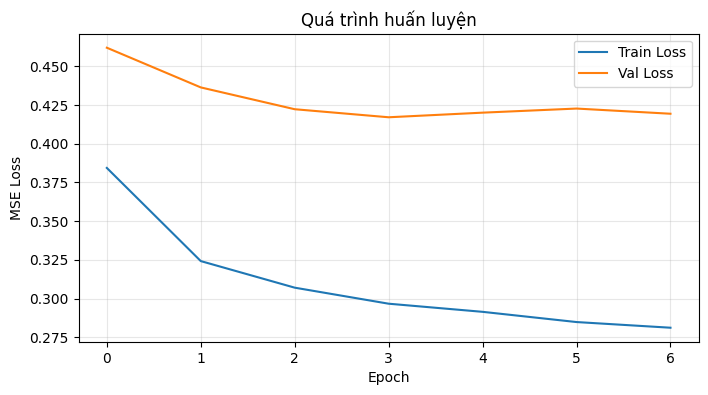

In [ ]:
model, history = train_model(model, train_loader, val_loader, configs)

plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Quá trình huấn luyện')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 13. Chỉ số đánh giá & hàm kiểm thử (test)

In [ ]:
def MAE(pred, true):
    return np.mean(np.abs(pred - true))

def MSE(pred, true):
    return np.mean((pred - true) ** 2)

def RMSE(pred, true):
    return np.sqrt(MSE(pred, true))

def MAPE(pred, true):
    return np.mean(np.abs((pred - true) / (true + 1e-8))) * 100

def metric(pred, true):
    return {
        'MAE': MAE(pred, true),
        'MSE': MSE(pred, true),
        'RMSE': RMSE(pred, true),
        'MAPE': MAPE(pred, true),
    }


def test_model(model, test_loader, configs):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for seq_x, seq_y, seq_x_mark, seq_y_mark in test_loader:
            seq_x = seq_x.float().to(configs.device)
            seq_y = seq_y.float().to(configs.device)
            seq_x_mark = seq_x_mark.float().to(configs.device)
            seq_y_mark = seq_y_mark.float().to(configs.device)

            dec_inp = torch.zeros_like(seq_y[:, -configs.pred_len:, :]).float()
            dec_inp = torch.cat([seq_y[:, :configs.label_len, :], dec_inp], dim=1).to(configs.device)

            outputs = model(seq_x, seq_x_mark, dec_inp, seq_y_mark)

            f_dim = -1 if configs.features == 'MS' else 0
            outputs = outputs[:, -configs.pred_len:, f_dim:]
            batch_y = seq_y[:, -configs.pred_len:, f_dim:]

            preds.append(outputs.detach().cpu().numpy())
            trues.append(batch_y.detach().cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    scores = metric(preds, trues)
    print('Kết quả kiểm thử (trên dữ liệu đã chuẩn hoá):')
    for k, v in scores.items():
        print(f'  {k}: {v:.4f}')

    return preds, trues, scores


## 14. Chạy kiểm thử (test)

In [ ]:
preds, trues, scores = test_model(model, test_loader, configs)


Kết quả kiểm thử (trên dữ liệu đã chuẩn hoá):
  MAE: 0.2413
  MSE: 0.2149
  RMSE: 0.4636
  MAPE: 188.8095


## 15. Trực quan hóa một mẫu dự báo

So sánh chuỗi dự báo (predicted) với chuỗi thực tế (ground-truth) cho một mẫu trong tập test,
trên cột target (kênh cuối cùng).


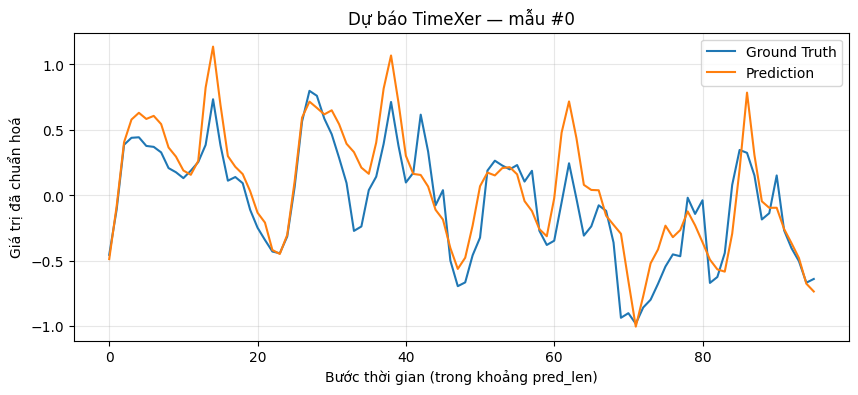

In [ ]:
sample_idx = 0       # đổi chỉ số mẫu muốn xem
channel_idx = -1     # -1 = cột target (cột cuối)

plt.figure(figsize=(10, 4))
plt.plot(trues[sample_idx, :, channel_idx], label='Ground Truth')
plt.plot(preds[sample_idx, :, channel_idx], label='Prediction')
plt.xlabel('Bước thời gian (trong khoảng pred_len)')
plt.ylabel('Giá trị đã chuẩn hoá')
plt.title(f'Dự báo TimeXer — mẫu #{sample_idx}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
